In [30]:
import nibabel as nib
import numpy as np
import hippomaps as hm
import pandas as pd
from glob import glob

In [31]:
# locate input data
pet_dir = '/data/mica3/MICA-PET/derivatives_REP/micapet'
dwi_dir = '/data/mica3/BIDS_MICs/derivatives/micapipe_v0.2.0/'
hippunfold_dir = '/data/mica3/BIDS_MICs/derivatives/hippunfold_v1.3.0/hippunfold'

# define which subjects and surfaces to examine
hemis = ['L','R']
labels = ['hipp']#,'dentate']
den = '0p5mm'
ses='ses-01'

# get expected number of vertices and their indices
nV,iV = hm.config.get_nVertices(labels,den)

features = ['Tau','FA', 'ADC', 'thickness']

In [43]:
df = pd.read_excel('Jordan-SPINDLE.xlsx')
df

,#,PX-EMU,Lateralization of epileptogenic focus,"Epileptogenic focus confirmed by the information of (sEEG/ site of surgical resection/ Ictal EEG abnormalities +/- MRI findings): FLE=forntal lobe epilepsy and cingulate epilepsy, CLE:central/midline epilepsy,ILE: insular epilepsy, mTLE=mesio-temporal lobe epilepsy, nTLE=neocortical lobe epilepsy, PQLE=posterior quadrant lobe epilepsy , multifocal epilepsy,IGE=ideopathic lobe epilepsy,unclear)",sex,sz onset,duration of epilepsy
0,1,PX012,L,mTLE,F,27,6
1,2,PX017,L,TLE,F,24,4
2,3,PX020,L,mTLE,M,50,2
3,4,PX025,R,mTLE,M,2,23
4,5,PX034,L,TLE,M,29,22
5,6,PX036,L,mTLE,M,18,6
6,7,PX044,R,mTLE,M,28,15
7,8,PX048,R,TLE,M,2,27
8,9,PX050,R,TLE,M,18,14
9,10,PX052,BL,mTLE,F,8,36


In [37]:
hippTau = np.ones((nV,2,len(df['PX-EMU']),len(features)))*np.nan
!mkdir -p tmp
for s,sub in enumerate(df['PX-EMU']):
    for h,hemi in enumerate(hemis):
        for f,feature in enumerate(features):
            surf = f'{hippunfold_dir}/sub-{sub}/{ses}/surf/sub-{sub}_{ses}_hemi-{hemi}_space-T1w_den-0p5mm_label-hipp_midthickness.surf.gii'
            if feature == 'Tau':
                volname = f'{pet_dir}/sub-{sub}/{ses}/pet/sub-{sub}_{ses}_pet-mkAVG-t1w_normalized.nii.gz'
                cmd = f'wb_command -volume-to-surface-mapping {volname} {surf} tmp/sub-{sub}_{ses}_hemi-{hemi}_{feature}.shape.gii -trilinear'
                !{cmd}
                try:
                    hippTau[:,h,s,f] = nib.load(f'tmp/sub-{sub}_{ses}_hemi-{hemi}_{feature}.shape.gii').darrays[0].data
                except:
                    print(f'tmp/sub-{sub}_{ses}_hemi-{hemi}_{feature}.shape.gii')
            elif feature=='thickness':
                try:
                    hippTau[:,h,s,f] = nib.load(f'{hippunfold_dir}/sub-{sub}/{ses}/surf/sub-{sub}_{ses}_hemi-{hemi}_space-T1w_den-0p5mm_label-hipp_thickness.shape.gii').darrays[0].data * nib.load(f'{hippunfold_dir}/sub-{sub}/{ses}/surf/sub-{sub}_{ses}_hemi-{hemi}_space-T1w_den-0p5mm_label-hipp_surfarea.shape.gii').darrays[0].data
                except:
                    print(f'{hippunfold_dir}/sub-{sub}/{ses}/surf/sub-{sub}_{ses}_hemi-{hemi}_space-T1w_den-0p5mm_label-hipp_thickness.shape.gii')
            else:
                volname = f'{dwi_dir}/sub-{sub}/{ses}/maps/sub-{sub}_{ses}_space-nativepro_model-DTI_map-{feature}.nii.gz'
                cmd = f'wb_command -volume-to-surface-mapping {volname} {surf} tmp/sub-{sub}_{ses}_hemi-{hemi}_{feature}.shape.gii -trilinear'
                !{cmd}
                try:
                    hippTau[:,h,s,f] = nib.load(f'tmp/sub-{sub}_{ses}_hemi-{hemi}_{feature}.shape.gii').darrays[0].data
                except:
                    print(f'tmp/sub-{sub}_{ses}_hemi-{hemi}_{feature}.shape.gii')
!rm -rf tmp*

In [44]:
data = {'sub':df['PX-EMU'], 
        'AvgTau_L': np.mean(hippTau[:,0,:,0],axis=0), 'AvgTau_R': np.mean(hippTau[:,1,:,0],axis=0),
        'AvgFA_L': np.mean(hippTau[:,0,:,1],axis=0), 'AvgFA_R': np.mean(hippTau[:,1,:,1],axis=0),
        'AvgADC_L': np.mean(hippTau[:,0,:,2],axis=0), 'AvgADC_R': np.mean(hippTau[:,1,:,2],axis=0),
        'AvgCV_L': np.mean(hippTau[:,0,:,3],axis=0), 'AvgCV_R': np.mean(hippTau[:,1,:,3],axis=0),
        }            
df2 = pd.DataFrame(data=data)
df2.to_csv('avgHippTau.csv')

/export03/data/opt/venv/lib/python3.8/site-packages/brainspace/plotting/base.py:287: UserWarning: Interactive mode requires 'panel'. Setting 'interactive=False'
  warnings.warn("Interactive mode requires 'panel'. "


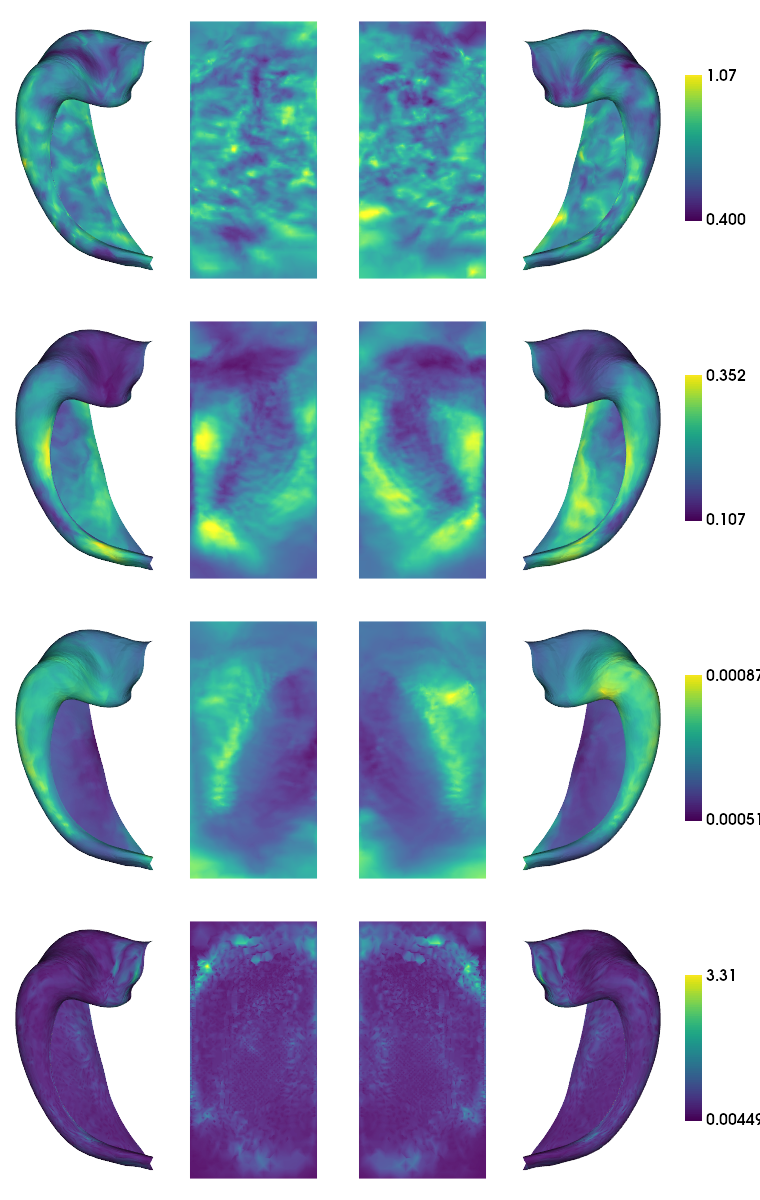

In [50]:
hm.plotting.surfplot_canonical_foldunfold(np.nanmean(hippTau,axis=2),labels=labels, hemis=hemis, tighten_cwindow=False, color_bar='right', share='row', den=den, embed_nb=True)

In [51]:
nV

7262